In [ ]:
try:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=False)

    print("Google Drive is mounted correctly")

except ModuleNotFoundError:

    print("Local environment detected (not Colab)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive is mounted correctly


In [ ]:
##########################################################################
# IMPORTS
##########################################################################

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress, t


In [ ]:
##########################################################################
# GENERAL SETTINGS
##########################################################################

class ConfigExperiment:
    def __init__(self):

        # File path
        self.route_files = (
            "/content/drive/MyDrive/Doctorado/Proyecto_ICF/reduccion 4-nf con aunps guamuchil y papalo-20260513T214938Z-3-001/"
        )

        # File
        self.files = [
            f"REDU H2O + 4NF + NaBH4 + 10uL polAuNPs PAPALO  {i}.TXT"
            for i in range(1, 10)
        ]

        self.files = [
            self.route_files + f
            for f in self.files
        ]

        # Experimental parameters
        self.m = 0.000000985
        self.M = 0.00065

        self.mass_molar_catalyst = 196.97
        self.mass_molar_contaminant = 663.575

        self.T = 298.15

        # Physical constants
        self.kb = 1.380649e-23
        self.h = 6.62607015e-34
        self.R = 8.314

        # Data for graphs
        self.val_first = [400]
        self.val_last = [230, 298]

        self.lambda_target = 400

In [ ]:
##########################################################################
# DATA READING AND PROCESSING
##########################################################################

class ReadUVVis:

    @staticmethod
    def extract_data(name_file):

        with open(name_file, 'r', encoding='latin1') as f:
            lines = f.readlines()

        start = None

        for i, line in enumerate(lines):

            if "Data Points" in line:
                start = i + 2
                break

        if start is None:
            raise ValueError(
                f"No ‘Data Points’ were found in {name_file}"
            )

        df = pd.read_csv(
            name_file,
            sep="\t",
            skiprows=start,
            names=["nm", "Abs"],
            encoding='latin1'
        )


        df = df.dropna()


        df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
        df["Abs"] = pd.to_numeric(df["Abs"], errors="coerce")


        df = df.dropna()

        return df


    @staticmethod
    def check_files(list_files):

        files_clean = []

        for file in list_files:


            if not os.path.exists(file):

                print(f"⚠️ File not found: {file}")

            else:


                files_clean.append(file)


                df = ReadUVVis.extract_data(file)


                name_exit = (
                    os.path.splitext(
                        os.path.basename(file)
                    )[0]
                    + "_clean.txt"
                )

                # Save as a plain text file
                df.to_csv(
                    config.route_files + name_exit,
                    sep="\t",
                    index=False
                )

        return files_clean


##########################################################################
# EXECUTION
##########################################################################

config = ConfigExperiment()

files_val = ReadUVVis.check_files(
    config.files
)

In [ ]:
##########################################################################
# STYLE SETTINGS
##########################################################################

class StylePlot:

    @staticmethod
    def apply_Style():

        plt.rcParams.update({
            "font.size": 14,
            "axes.labelsize": 14,
            "axes.titlesize": 14,
            "legend.fontsize": 12,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "axes.linewidth": 1.5,
            "lines.linewidth": 2,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "axes.labelweight": "bold",
            "axes.titleweight": "bold"
        })


In [ ]:
##########################################################################
# UV-VIS PLOTTER
##########################################################################

class plotUVVis:

    def __init__(self, config):

        self.config = config
        self.y_first = {}
        self.y_last = {}

    def plot_specters(self):

        plt.figure(figsize=(10, 6))

        StylePlot.apply_Style()

        for i, file in enumerate(self.config.files):

            df = ReadUVVis.extract_data(file)

            self._plot_curve(df, i)
            self._save_lines_reference(df, i)

        self._draw_lines_vertical()
        self._draw_arrow()
        self._config_axis()
        self._save_figure()

        plt.show()

    def _plot_curve(self, df, index):

        plt.plot(
            df["nm"],
            df["Abs"],
            label=rf"$\mathrm{{4NP}}_{{{index+1}}}$"
        )

    def _save_lines_reference(self, df, index):

        if index == 0:
            for x_nm in self.config.val_first:

                y_nm = df.loc[
                    (df["nm"] - x_nm).abs().idxmin(),
                    "Abs"
                ]

                self.y_first[x_nm] = y_nm

        if index == len(self.config.files) - 1:
            for x_nm in self.config.val_last:

                y_nm = df.loc[
                    (df["nm"] - x_nm).abs().idxmin(),
                    "Abs"
                ]

                self.y_last[x_nm] = y_nm

    def _draw_lines_vertical(self):

        for x_nm, y_nm in self.y_first.items():

            plt.vlines(
                x_nm,
                0,
                y_nm,
                linestyles='dashed',
                alpha=0.7
            )

            plt.text(
                x_nm,
                y_nm,
                rf'${x_nm}\ \mathrm{{nm}}$',
                fontsize=11,
                ha='left',
                va='bottom'
            )

        for x_nm, y_nm in self.y_last.items():

            plt.vlines(
                x_nm,
                0,
                y_nm,
                linestyles='dashed',
                alpha=0.7
            )

            plt.text(
                x_nm,
                y_nm,
                rf'${x_nm}\ \mathrm{{nm}}$',
                fontsize=11,
                ha='left',
                va='bottom'
            )

    def _draw_arrow(self):

        # Down arrow
        plt.annotate(
            '',
            xy=(470, 2),
            xytext=(470, 12),
            arrowprops=dict(
                arrowstyle='->',
                linewidth=1.3,
                color='black'
            )
        )

        plt.text(
            480,
            11,
            "100%\n16 min",
            color='red',
            fontsize=12,
            ha='center',
            va='center',
            linespacing=1.2
        )

        # UP arrow
        plt.annotate(
            '',
            xy=(280, 4),
            xytext=(280, 1.8),
            arrowprops=dict(
                arrowstyle='->',
                linewidth=1.3,
                color='black'
            )
        )

        plt.text(
            300,
            5,
            "100%\n10 min",
            color='red',
            fontsize=12,
            ha='center',
            va='center',
            linespacing=1.2
        )

    def _config_axis(self):

        plt.xlabel(
            r'Wavelength $\lambda$ (nm)',
            fontsize=14
        )

        plt.ylabel(
            r'Absorbance (a.u.)',
            fontsize=14
        )

        plt.title(
            r'REDU H2O + 4NF + NaBH4 + 10uL polAuNPs PAPALO',
            fontsize=14
        )
        ######################################
        # Block for manual graph editing
        ######################################
        plt.xlim(200, 500)
        plt.ylim(0, None)

        ymin, ymax = plt.ylim()
        #xmin, xmax = plt.xlim()

        plt.xticks(np.arange(200, 501, 50))
        plt.yticks(np.arange(0, ymax + 1, 2))

        plt.tick_params(axis='x', direction='out')
        #####################################

        plt.tight_layout()

    def _save_figure(self):

        plt.savefig(
           self.config.route_files + "uv_vis.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.route_files + "uv_vis.tif",
            dpi=600,
            bbox_inches='tight'
        )

In [ ]:
##########################################################################
# ANALYSIS CLASS
##########################################################################

class analysisUVVis:

    def __init__(self, config):

        self.config = config

        self.abs_lambda = None
        self.x = None
        self.abs_norm = None
        self.log_abs = None

        self.result_regression = None

    ######################################################################
    # EXTRACT ABSORBANCE
    ######################################################################

    def extract_absorbance(self):

        abs_lambda = []

        for file in self.config.files:

            df = ReadUVVis.extract_data(file)

            if df is None:
                continue

            raw = df.iloc[
                (df["nm"] - self.config.lambda_target)
                .abs()
                .argsort()[:1]
            ]

            abs_lambda.append(
                raw["Abs"].values[0]
            )

        self.abs_lambda = abs_lambda

        self.x = np.arange(
            0,
            2 * len(abs_lambda),
            2
        )

        table = pd.DataFrame({
            "X": self.x,
            f"Abs_{self.config.lambda_target}":
            self.abs_lambda
        })

        print(f"\nTABLE 1 (Abs a {self.config.lambda_target} nm)")
        print(table)

    ######################################################################
    # ABSORBANCE PLOTTER
    ######################################################################

    def plot_absorbance(self):

        plt.figure()

        plt.plot(
            self.x,
            self.abs_lambda,
            marker='o'
        )

        plt.title(
            f"Absorbance to {self.config.lambda_target} nm"
        )

        plt.xlabel(r'Time (min)')
        plt.ylabel(r'Absorbance (a.u.)')

        plt.savefig(
            self.config.route_files + "abs.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.route_files + "abs.tif",
            dpi=600,
            bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # NORMALIZE
    ######################################################################

    def normalize(self):

        abs0 = self.abs_lambda[0]

        self.abs_norm = [
            a / abs0
            for a in self.abs_lambda
        ]

        table = pd.DataFrame({
            "X": self.x,
            "Abs_norm": self.abs_norm
        })

        print("\nTABLE 2 (Normalize)")
        print(table)

    ######################################################################
    # NORMALIZE PLOTTER
    ######################################################################

    def plot_normalized(self):

        plt.figure()

        plt.plot(
            self.x,
            self.abs_norm,
            marker='o'
        )

        plt.title(
            f"Normalize Absorbance ({self.config.lambda_target} nm)"
        )

        plt.xlabel(r'Time (min)')
        plt.ylabel(r"$A_t/A_0$")

        plt.savefig(
            self.config.route_files + "normalized.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.route_files + "normalized.tif",
            dpi=600,
            bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # LINEAR REGRESSION
    ######################################################################

    def regression_lineal(self):

        self.log_abs = np.log(
            self.abs_norm
        )

        result = linregress(
            self.x,
            self.log_abs
        )

        self.result_regression = result

        # =========================
        # Parameters
        # =========================

        slope = result.slope
        intercept = result.intercept

        stderr_slope = result.stderr
        stderr_intercept = result.intercept_stderr

        r2 = result.rvalue**2

        k = -slope

        y_fit = slope * self.x + intercept

        # =========================
        # Confidence intervals
        # =========================

        n = len(self.x)

        alpha = 0.05

        t_crit = t.ppf(
            1 - alpha/2,
            df=n-2
        )

        ic_slope = (
            slope - t_crit * stderr_slope,
            slope + t_crit * stderr_slope
        )

        ic_intercept = (
            intercept - t_crit * stderr_intercept,
            intercept + t_crit * stderr_intercept
        )

        ic_k = (
            -ic_slope[1],
            -ic_slope[0]
        )

        # =========================
        # Table
        # =========================

        table = pd.DataFrame({
            "X": self.x,
            "ln(Abs_norm)": self.log_abs
        })

        print("\nTABLE 3 (Log)")
        print(table)

        # =========================
        # PLOT
        # =========================

        plt.figure()

        plt.plot(
            self.x,
            self.log_abs,
            'o',
            label="Data"
        )

        plt.plot(
            self.x,
            y_fit,
            '-',
            label="Linear regression"
        )

        plt.title("Linear regression (ln A)")

        plt.xlabel(r'Time (min)')
        plt.ylabel(r"ln($A_t/A_0$)")

        plt.legend()

        plt.savefig(
            self.config.route_files + "regression.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.route_files + "regression.tif",
            dpi=600,
            bbox_inches='tight'
        )

        plt.show()

        # =========================
        # Results
        # =========================

        print(f"\nSlope = {slope:.6f}")

        print(
            f"Standard error of the slope = "
            f"{stderr_slope:.6f}"
        )

        print(
            f"IC 95% slope = "
            f"[{ic_slope[0]:.6f}, "
            f"{ic_slope[1]:.6f}]"
        )

        print(f"\nIntercept = {intercept:.6f}")

        print(
            f"Standard error of intercept = "
            f"{stderr_intercept:.6f}"
        )

        print(
            f"IC 95% intercept = "
            f"[{ic_intercept[0]:.6f}, "
            f"{ic_intercept[1]:.6f}]"
        )

        print(f"\nR² = {r2:.6f}")

        print(f"\nConstant speed k = {k:.6f}")

        print(
            f"IC 95% k = "
            f"[{ic_k[0]:.6f}, "
            f"{ic_k[1]:.6f}]"
        )

        # =========================
        # RESIDUE
        # =========================

        residue = (
            self.log_abs - y_fit
        )

        table_residue = pd.DataFrame({

            "Time": self.x,

            "Experimental value":
            self.log_abs,

            "Adjusted value":
            y_fit,

            "Residue":
            residue
        })

        print("\nRESIDUES TABLE:")
        print(table_residue)

        # =========================
        #  RESIDUE PLOTTER
        # =========================

        plt.figure()

        plt.axhline(
            0,
            linestyle='--',
            linewidth=1.5
        )

        plt.plot(
            self.x,
            residue,
            'o-'
        )

        plt.xlabel(r'Time (min)')
        plt.ylabel(r'Residues')

        plt.title(
            'Residue analysis'
        )

        plt.savefig(
            self.config.route_files
            + "residue.pdf",

           dpi=600,

            bbox_inches='tight'
        )

        plt.savefig(
            self.config.route_files
            + "residue.tif",

            dpi=600,

           bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # COMBINED PLOT
    ######################################################################

    def plot_combined(self):

        slope = self.result_regression.slope

        intercept = self.result_regression.intercept

        y_fit = (
            slope * self.x
            + intercept
        )

        # =========================
        # FIGURE
        # =========================

        fig, ax1 = plt.subplots(
            figsize=(7,5)
        )

        # ---------------------------------
        # LEFT Y AXIS : NORMALIZED
        # ---------------------------------

        ax1.plot(
            self.x,
            self.abs_norm,
            'o-',
            label=r"$A_t/A_0$"
        )

        ax1.set_xlabel(
            r"Time (min)"
        )

        ax1.set_ylabel(
            r"$A_t/A_0$"
        )

        # ax1.set_xlim(0, 60)
        # ax1.set_ylim(0, 1.2)

        # ---------------------------------
        # RIGHT Y AXIS : LOG + REGRESSION
        # ---------------------------------

        ax2 = ax1.twinx()

        ax2.plot(
            self.x,
            self.log_abs,
            's-',
            label=r"ln($A_t/A_0$)"
        )

        ax2.plot(
            self.x,
            y_fit,
            '-',
            label="linear regression"
        )

        ax2.set_ylabel(
            r"ln($A_t/A_0$)"
        )

        ax2.set_ylim(
            0.005,
            -4.035
        )

        # ---------------------------------
        # LABELS
        # ---------------------------------

        lines1, labels1 = (
            ax1.get_legend_handles_labels()
        )

        lines2, labels2 = (
            ax2.get_legend_handles_labels()
        )

        ax1.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc='upper center'
        )

        # ---------------------------------
        # TITLE
        # ---------------------------------

        plt.title(
            'combined plot'
        )


        plt.tight_layout()

        plt.savefig(
            self.config.route_files
            + "norm_regression_combined.pdf",

            dpi=600,

            bbox_inches='tight'
        )

        plt.savefig(
            self.config.route_files
            + "norm_regression_combined.tif",

            dpi=600,

            bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # EFFICIENCY
    ######################################################################

    def calcule_efficiency(self):

        abs0 = self.abs_lambda[0]
        abs_final = self.abs_lambda[-1]

        efficiency = (
            (abs0 - abs_final)
            / abs0
        ) * 100

        print(
            f"\nEfficiency = {efficiency:.2f}%"
        )

        return efficiency

In [ ]:
##########################################################################
# CATALYTIC PARAMETERS
##########################################################################

def calcule_parameters_catalytic(self):

    slope = self.result_regression.slope

    stderr_slope = (
        self.result_regression.stderr
    )

    k = -slope

    abs0 = self.abs_lambda[0]

    abs_final = self.abs_lambda[-1]

    efficiency = (
        (abs0 - abs_final)
        / abs0
    ) * 100

    # =========================
    # k'
    # =========================

    k_prime = (
        k / self.config.m
    )

    print(f"\nk′ = {k_prime:.6f}")

    # =========================
    # Qt
    # =========================

    Qt = (
        (abs0 - abs_final)
        * self.config.M
        / self.config.m
    )

    print(f"\nQt = {Qt:.6f} g/g")

    # =========================
    # ΔG‡
    # =========================

    k_seg = k / 60

    stderr_k = (
        stderr_slope / 60
    )

    delta_G = (
        self.config.R
        * self.config.T
        * np.log(
            (
                self.config.kb
                * self.config.T
            )
            /
            (
                self.config.h
                * k_seg
            )
        )
    )

    delta_G_kJ = delta_G / 1000

    error_delta_G = (
        self.config.R
        * self.config.T
        * (stderr_k / k_seg)
    ) / 1000

    n = len(self.x)

    alpha = 0.05

    t_crit = t.ppf(
        1 - alpha/2,
        df=n-2
    )

    ic_delta_G = (
        delta_G_kJ
        - t_crit * error_delta_G,

        delta_G_kJ
        + t_crit * error_delta_G
    )

    print(
        f"\nΔG‡ = "
        f"{delta_G_kJ:.4f} kJ/mol"
    )

    print(
        f"Standard error ΔG‡ = "
        f"±{error_delta_G:.4f} kJ/mol"
    )

    print(
        f"IC95% ΔG‡ = "
        f"[{ic_delta_G[0]:.4f}, "
        f"{ic_delta_G[1]:.4f}]"
    )

    # =========================
    # TON y TOF
    # =========================

    time_react_min = (
        self.x[-1]
    )

    frac_deg = (
        efficiency / 100
    )

    mass_contaminant_deg = (
        self.config.M
        * frac_deg
    )

    moles_contaminant = (
        mass_contaminant_deg
        /
        self.config.mass_molar_contaminant
    )

    moles_catalyst = (
        self.config.m
        /
        self.config.mass_molar_catalyst
    )

    TON = (
        moles_contaminant
        /
        moles_catalyst
    )

    TOF = (
        TON
        /
        time_react_min
    )

    print(f"\nTON = {TON:.6f}")

    print(f"TOF = {TOF:.6f} min^-1")


analysisUVVis.calcule_parameters_catalytic = calcule_parameters_catalytic

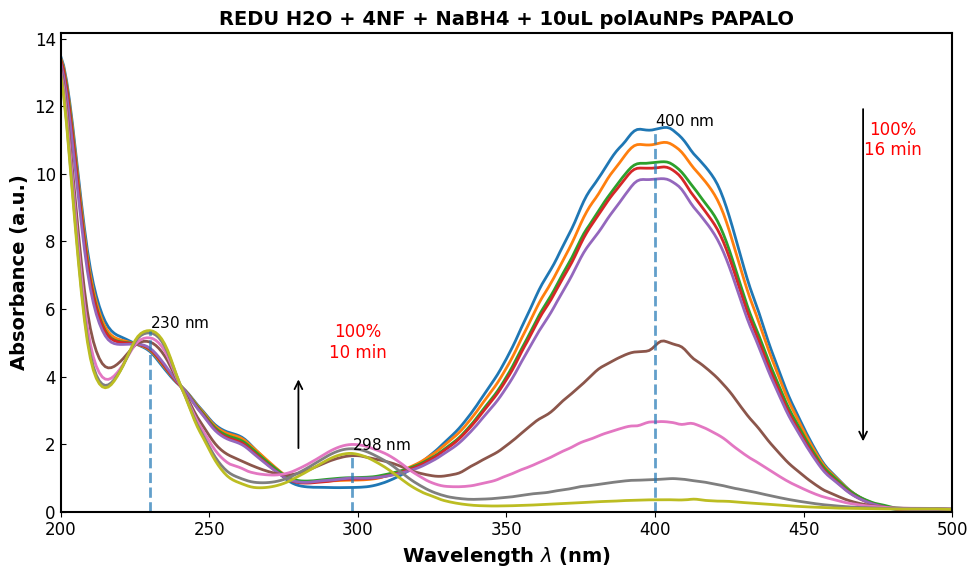


TABLE 1 (Abs a 400 nm)
    X    Abs_400
0   0  11.316117
1   2  10.878126
2   4  10.337185
3   6  10.175687
4   8   9.845025
5  10   4.911963
6  12   2.658164
7  14   0.953891
8  16   0.352911


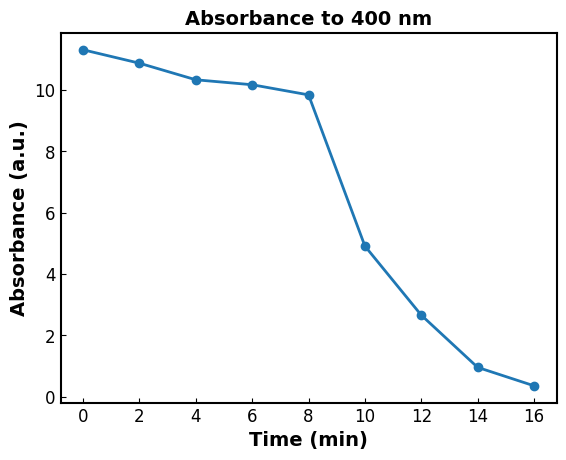


TABLE 2 (Normalize)
    X  Abs_norm
0   0  1.000000
1   2  0.961295
2   4  0.913492
3   6  0.899221
4   8  0.870000
5  10  0.434068
6  12  0.234901
7  14  0.084295
8  16  0.031187


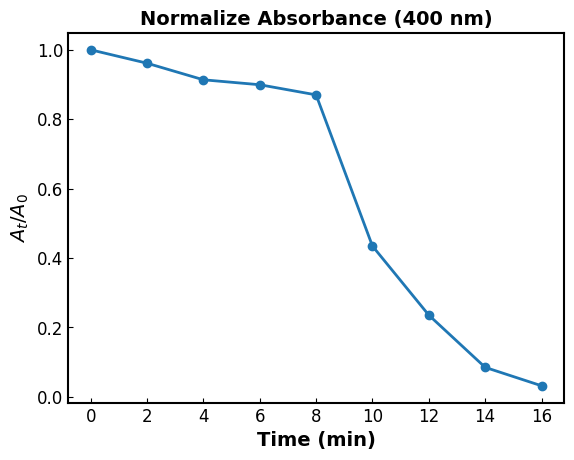


TABLE 3 (Log)
    X  ln(Abs_norm)
0   0      0.000000
1   2     -0.039474
2   4     -0.090480
3   6     -0.106227
4   8     -0.139262
5  10     -0.834554
6  12     -1.448593
7  14     -2.473434
8  16     -3.467766


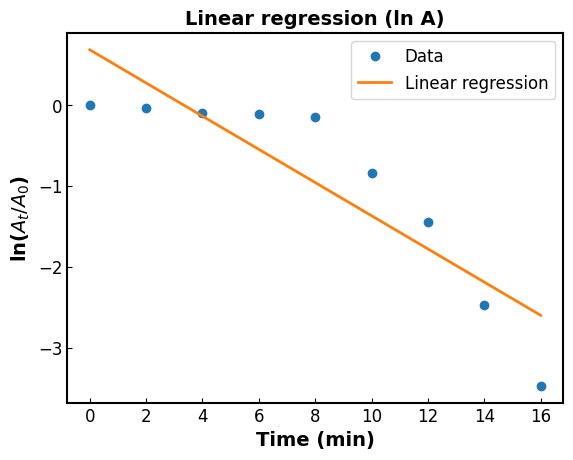


Slope = -0.205146
Standard error of the slope = 0.039798
IC 95% slope = [-0.299252, -0.111039]

Intercept = 0.685634
Standard error of intercept = 0.378949
IC 95% intercept = [-0.210439, 1.581707]

R² = 0.791488

Constant speed k = 0.205146
IC 95% k = [0.111039, 0.299252]

RESIDUES TABLE:
   Time  Experimental value  Adjusted value   Residue
0     0            0.000000        0.685634 -0.685634
1     2           -0.039474        0.275343 -0.314817
2     4           -0.090480       -0.134949  0.044469
3     6           -0.106227       -0.545241  0.439014
4     8           -0.139262       -0.955532  0.816271
5    10           -0.834554       -1.365824  0.531270
6    12           -1.448593       -1.776115  0.327523
7    14           -2.473434       -2.186407 -0.287027
8    16           -3.467766       -2.596699 -0.871068


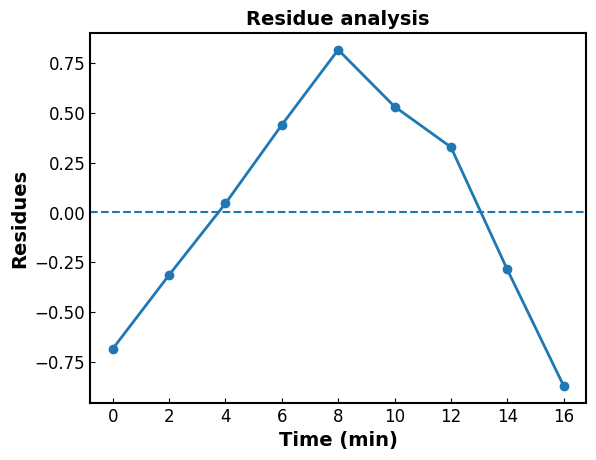

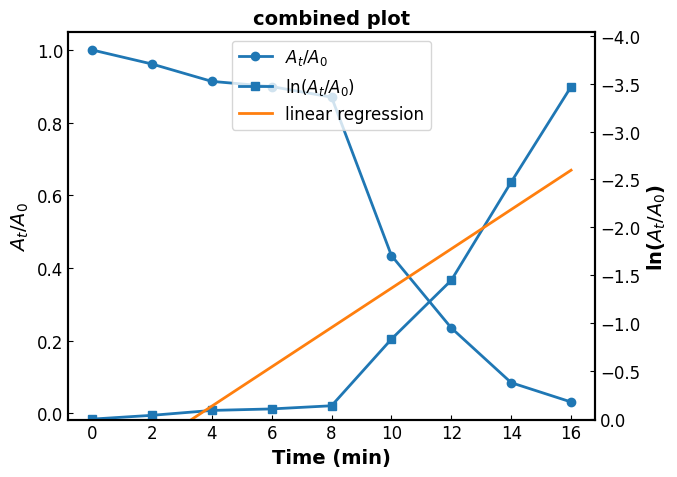


Efficiency = 96.88%

k′ = 208269.855084

Qt = 7234.602548 g/g

ΔG‡ = 87.0957 kJ/mol
Standard error ΔG‡ = ±0.4809 kJ/mol
IC95% ΔG‡ = [85.9586, 88.2328]

TON = 189.769898
TOF = 11.860619 min^-1


In [ ]:
##########################################################################
# MAIN EXECUTION
##########################################################################

config = ConfigExperiment()

ReadUVVis.check_files(config.files)

plot = plotUVVis(config)

plot.plot_specters()

config = ConfigExperiment()

analysis = analysisUVVis(config)

analysis.extract_absorbance()

analysis.plot_absorbance()

analysis.normalize()

analysis.plot_normalized()

analysis.regression_lineal()

analysis.plot_combined()

analysis.calcule_efficiency()

analysis.calcule_parameters_catalytic()
